# MLP Regressora — Previsão de Deslocamento de Sistemas Convectivos
 carregamento → split temporal → Random Search com CV temporal → treino final → avaliação vs baseline → figuras e tabelas para o artigo.

## 1. Imports e Configurações Globais

In [ ]:
# --- Google Drive (descomente se usar Colab) ---
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── Caminhos ──────────────────────────────────────────────────────────────────
CSV_URL = "https://raw.githubusercontent.com/sialm2020/MLP-no-rasreamento-de-sistemas-convectivos-com-TATHU/main/Results/dataset_mlp_regressao_deslocamento.csv"

OUT_DIR = "/content/resultados_mlp"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Carregar dataset ──────────────────────────────────────────────────────────
df_mlp_reg = pd.read_csv(CSV_URL)

print("Dataset carregado:")
print(df_mlp_reg.shape)
display(df_mlp_reg.head())
# ── Reprodutibilidade ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Features e targets ────────────────────────────────────────────────────────
FEATURES = [
    "log_area_km2", "log_count",
    "tb_min", "tb_mean", "tb_std",
    "lon_curr", "lat_curr",
    "delta_lon", "delta_lat"
]
TARGETS = ["target_delta_lon", "target_delta_lat"]

# ── Datas de corte ────────────────────────────────────────────────────────────
TEST_START = pd.Timestamp("2011-06-25")
TEST_END   = pd.Timestamp("2011-06-30")

# ── Hiperparâmetros fixos ─────────────────────────────────────────────────────
N_EPOCHS   = 200
MIN_DELTA  = 0.0001
N_SPLITS   = 4
N_ITER_RS  = 20   # iterações do Random Search

print("Configurações OK.")

Mounted at /content/drive
Dataset carregado:
(1119, 26)


,name,timestamp_prev,timestamp_curr,lon_prev,lat_prev,lon_curr,lat_curr,delta_lon,delta_lat,event,...,touching_right,touching_up,touching_down,dt_horas,timestamp_next,target_delta_lon,target_delta_lat,dt_target_horas,log_area_km2,log_count
0,00022954-58bd-4674-adca-78ccd488dc27,2011-06-07 00:00:00,2011-06-07 01:00:00,-55.872798,-1.876015,-56.068922,-2.029962,-0.196124,-0.153947,CONTINUITY,...,False,False,False,1.0,2011-06-07 02:00:00,-0.374096,0.214889,1.0,9.444701,6.673298
1,0024c54f-70cd-4d68-a18b-02d0cc5e0f43,2011-06-17 00:00:00,2011-06-17 01:00:00,-71.337056,-0.764516,-71.435082,-0.625620,-0.098026,0.138896,CONTINUITY,...,False,False,False,1.0,2011-06-17 02:00:00,-0.194201,-0.100334,1.0,9.723463,6.951772
2,0024c54f-70cd-4d68-a18b-02d0cc5e0f43,2011-06-17 01:00:00,2011-06-17 02:00:00,-71.435082,-0.625620,-71.629283,-0.725954,-0.194201,-0.100334,CONTINUITY,...,False,False,False,1.0,2011-06-17 03:00:00,-0.256250,-0.091336,1.0,10.098437,7.326466
3,0024c54f-70cd-4d68-a18b-02d0cc5e0f43,2011-06-17 02:00:00,2011-06-17 03:00:00,-71.629283,-0.725954,-71.885533,-0.817290,-0.256250,-0.091336,CONTINUITY,...,False,False,False,1.0,2011-06-17 04:00:00,-0.270416,-0.203522,1.0,10.391853,7.619724
4,0024c54f-70cd-4d68-a18b-02d0cc5e0f43,2011-06-17 03:00:00,2011-06-17 04:00:00,-71.885533,-0.817290,-72.155949,-1.020812,-0.270416,-0.203522,CONTINUITY,...,False,False,False,1.0,2011-06-17 05:00:00,-0.269749,-0.181455,1.0,10.610168,7.837949


Configurações OK.


## 2. Carregamento e Organização do Dataset

In [ ]:
df = pd.read_csv(CSV_URL)

# Converter colunas de data de uma vez
for col in ["timestamp_prev", "timestamp_curr", "timestamp_next"]:
    df[col] = pd.to_datetime(df[col])

print("Shape:", df.shape)
print("Período:", df["timestamp_curr"].min(), "→", df["timestamp_curr"].max())
print(df.head())

Shape: (1119, 26)
Período: 2011-06-07 01:00:00 → 2011-06-29 17:00:00
                                   name      timestamp_prev  \
0  00022954-58bd-4674-adca-78ccd488dc27 2011-06-07 00:00:00   
1  0024c54f-70cd-4d68-a18b-02d0cc5e0f43 2011-06-17 00:00:00   
2  0024c54f-70cd-4d68-a18b-02d0cc5e0f43 2011-06-17 01:00:00   
3  0024c54f-70cd-4d68-a18b-02d0cc5e0f43 2011-06-17 02:00:00   
4  0024c54f-70cd-4d68-a18b-02d0cc5e0f43 2011-06-17 03:00:00   

       timestamp_curr   lon_prev  lat_prev   lon_curr  lat_curr  delta_lon  \
0 2011-06-07 01:00:00 -55.872798 -1.876015 -56.068922 -2.029962  -0.196124   
1 2011-06-17 01:00:00 -71.337056 -0.764516 -71.435082 -0.625620  -0.098026   
2 2011-06-17 02:00:00 -71.435082 -0.625620 -71.629283 -0.725954  -0.194201   
3 2011-06-17 03:00:00 -71.629283 -0.725954 -71.885533 -0.817290  -0.256250   
4 2011-06-17 04:00:00 -71.885533 -0.817290 -72.155949 -1.020812  -0.270416   

   delta_lat       event  ...  touching_right  touching_up  touching_down  \
0  -0.

## 3. Split Temporal (treino/validação/teste)

In [ ]:
def filtrar_periodo(df, inicio, fim):
    """Mantém apenas linhas em que prev, curr e next caem dentro do intervalo [inicio, fim)."""
    mask = (
        (df["timestamp_prev"] >= inicio) & (df["timestamp_prev"] < fim) &
        (df["timestamp_curr"] >= inicio) & (df["timestamp_curr"] < fim) &
        (df["timestamp_next"] >= inicio) & (df["timestamp_next"] < fim)
    )
    return df[mask].copy()


# Dados disponíveis para CV (tudo anterior ao teste final)
df_model = df[df["timestamp_next"] < TEST_START].copy()

# Teste final reservado
df_test_final = filtrar_periodo(df, TEST_START, TEST_END)

for nome, subdf in [("CV (treino+val)", df_model), ("Teste final", df_test_final)]:
    print(f"{nome}: {subdf.shape[0]} amostras | "
          f"{subdf['timestamp_curr'].min()} → {subdf['timestamp_curr'].max()}")

CV (treino+val): 864 amostras | 2011-06-07 01:00:00 → 2011-06-24 17:00:00
Teste final: 255 amostras | 2011-06-25 01:00:00 → 2011-06-29 17:00:00


## 4. Funções Utilitárias
Centraliza lógica reutilizada: geração de folds, normalização, criação de DataLoaders, treino de um fold e cálculo de métricas.

In [ ]:
# ── Modelo ────────────────────────────────────────────────────────────────────

class MLPRegressorFlexible(nn.Module):
    """MLP com número variável de camadas ocultas."""

    def __init__(self, input_dim, hidden_layers, output_dim=2, dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_layers:
            layers += [nn.Linear(prev_dim, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Pré-processamento ─────────────────────────────────────────────────────────

def preparar_dados(df_train, df_val, features, targets, batch_size, seed=SEED):
    """Normaliza e converte para tensores/DataLoaders. Retorna um dict com tudo."""
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_tr = scaler_X.fit_transform(df_train[features].values)
    X_va = scaler_X.transform(df_val[features].values)

    y_tr = scaler_y.fit_transform(df_train[targets].values)
    y_va = scaler_y.transform(df_val[targets].values)

    def to_tensor(arr):
        return torch.tensor(arr, dtype=torch.float32)

    X_tr_t, y_tr_t = to_tensor(X_tr), to_tensor(y_tr)
    X_va_t, y_va_t = to_tensor(X_va), to_tensor(y_va)

    loader_tr = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    loader_va = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=batch_size, shuffle=False)

    return dict(
        scaler_X=scaler_X, scaler_y=scaler_y,
        X_tr_t=X_tr_t, y_tr_t=y_tr_t,
        X_va_t=X_va_t, y_va_t=y_va_t,
        loader_tr=loader_tr, loader_va=loader_va,
        y_va_orig=df_val[targets].values
    )


# ── Loop de treino ────────────────────────────────────────────────────────────

def treinar_modelo(model, loader_tr, loader_va, learning_rate,
                   n_epochs=N_EPOCHS, patience=15, min_delta=MIN_DELTA):
    """Treina com early stopping. Retorna model restaurado e histórico de losses."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val  = float("inf")
    best_ep   = 0
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # Treino
        model.train()
        run = 0.0
        for Xb, yb in loader_tr:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            run += loss.item() * Xb.size(0)
        train_losses.append(run / len(loader_tr.dataset))

        # Validação
        model.eval()
        run = 0.0
        with torch.no_grad():
            for Xb, yb in loader_va:
                run += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss = run / len(loader_va.dataset)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val - min_delta:
            best_val, best_ep = val_loss, epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Época {epoch+1:03d} | treino {train_losses[-1]:.4f} "
                  f"| val {val_loss:.4f} | melhor época {best_ep}")

        if no_improve >= patience:
            print(f"  Early stopping na época {epoch+1} (melhor: {best_ep}, val: {best_val:.4f})")
            break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_ep


# ── Métricas ──────────────────────────────────────────────────────────────────

def calcular_metricas(y_true, y_pred):
    """Retorna dict com MAE, RMSE e R² para lon e lat, mais médias."""
    metricas = {}
    for i, eixo in enumerate(["lon", "lat"]):
        metricas[f"mae_{eixo}"]  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        metricas[f"rmse_{eixo}"] = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        metricas[f"r2_{eixo}"]   = r2_score(y_true[:, i], y_pred[:, i])
    metricas["mae_medio"]  = np.mean([metricas["mae_lon"],  metricas["mae_lat"]])
    metricas["rmse_medio"] = np.mean([metricas["rmse_lon"], metricas["rmse_lat"]])
    return metricas


# ── Geração de folds ──────────────────────────────────────────────────────────

def gerar_folds(df_model, n_splits=N_SPLITS):
    """Retorna lista de (df_train_fold, df_val_fold) com janela expansiva."""
    unique_times = np.array(sorted(df_model["timestamp_curr"].unique()))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for train_idx, val_idx in tscv.split(unique_times):
        t_ini, t_fim = pd.Timestamp(unique_times[train_idx].min()), pd.Timestamp(unique_times[train_idx].max())
        v_ini, v_fim = pd.Timestamp(unique_times[val_idx].min()),   pd.Timestamp(unique_times[val_idx].max())
        df_tr = df_model[
            (df_model["timestamp_prev"] >= t_ini) & (df_model["timestamp_prev"] <= t_fim) &
            (df_model["timestamp_curr"] >= t_ini) & (df_model["timestamp_curr"] <= t_fim) &
            (df_model["timestamp_next"] >= t_ini) & (df_model["timestamp_next"] <= t_fim)
        ].copy()
        df_va = df_model[
            (df_model["timestamp_prev"] >= v_ini) & (df_model["timestamp_prev"] <= v_fim) &
            (df_model["timestamp_curr"] >= v_ini) & (df_model["timestamp_curr"] <= v_fim) &
            (df_model["timestamp_next"] >= v_ini) & (df_model["timestamp_next"] <= v_fim)
        ].copy()
        folds.append((df_tr, df_va, t_ini, t_fim, v_ini, v_fim))
    return folds


print("Funções utilitárias definidas.")

Funções utilitárias definidas.


## 5. Visualização dos Folds Temporais

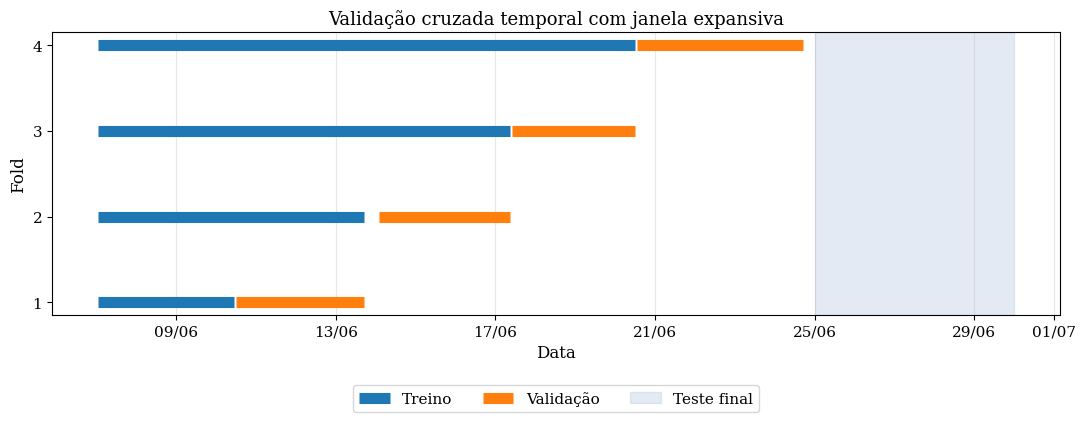

In [ ]:
folds = gerar_folds(df_model, N_SPLITS)

plt.rcParams.update({"font.family": "serif", "font.size": 11,
                     "axes.titlesize": 13, "axes.labelsize": 12})

fig, ax = plt.subplots(figsize=(11, 4.5))
cor_tr, cor_va = "tab:blue", "tab:orange"

for i, (df_tr, df_va, t_ini, t_fim, v_ini, v_fim) in enumerate(folds, start=1):
    ax.plot([t_ini, t_fim], [i, i], color=cor_tr, linewidth=8, solid_capstyle="butt",
            label="Treino" if i == 1 else None)
    ax.plot([v_ini, v_fim], [i, i], color=cor_va, linewidth=8, solid_capstyle="butt",
            label="Validação" if i == 1 else None)

ax.axvspan(TEST_START, TEST_END, color="lightsteelblue", alpha=0.35, label="Teste final")
ax.set_yticks(range(1, N_SPLITS + 1))
ax.set_ylabel("Fold")
ax.set_xlabel("Data")
ax.set_title("Validação cruzada temporal com janela expansiva")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "folds_temporais.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Random Search com Validação Cruzada Temporal

In [ ]:
SEARCH_SPACE = {
    "hidden_layers": [[16,16],[32,16],[32,32],[64,32],[64,64],[128,64]],
    "dropout":       [0.0, 0.1, 0.2, 0.3],
    "learning_rate": [0.0005, 0.001, 0.002],
    "batch_size":    [32, 64, 128],
    "patience":      [10, 15, 20]
}


def sortear_combinacoes(space, n_iter=N_ITER_RS, seed=SEED):
    random.seed(seed)
    combos = []
    for i in range(n_iter):
        p = {k: random.choice(v) for k, v in space.items()}
        p["id"] = i + 1
        p["nome"] = (
            f"{'-'.join(map(str, p['hidden_layers']))}_"
            f"d{p['dropout']}_lr{p['learning_rate']}_b{p['batch_size']}"
        )
        combos.append(p)
    return combos


def random_search_cv(df_model, space, features, targets,
                     n_iter=N_ITER_RS, n_splits=N_SPLITS, seed=SEED):
    combos = sortear_combinacoes(space, n_iter, seed)
    folds  = gerar_folds(df_model, n_splits)
    resultados = []

    for p in combos:
        print(f"\n{'='*70}")
        print(f"Busca {p['id']}/{n_iter}: {p['nome']}")

        for fold_i, (df_tr, df_va, t_ini, t_fim, v_ini, v_fim) in enumerate(folds, start=1):
            if len(df_tr) == 0 or len(df_va) == 0:
                print(f"  Fold {fold_i}: ignorado (sem amostras).")
                continue

            print(f"  Fold {fold_i} | treino {len(df_tr)} | val {len(df_va)}")

            torch.manual_seed(seed + p["id"] + fold_i)
            dados = preparar_dados(df_tr, df_va, features, targets, p["batch_size"])

            model = MLPRegressorFlexible(
                input_dim=len(features),
                hidden_layers=p["hidden_layers"],
                output_dim=len(targets),
                dropout=p["dropout"]
            )

            model, _, _, best_ep = treinar_modelo(
                model, dados["loader_tr"], dados["loader_va"],
                learning_rate=p["learning_rate"],
                patience=p["patience"]
            )

            model.eval()
            with torch.no_grad():
                y_pred = dados["scaler_y"].inverse_transform(
                    model(dados["X_va_t"]).numpy()
                )

            m = calcular_metricas(dados["y_va_orig"], y_pred)
            print(f"    RMSE médio: {m['rmse_medio']:.4f}")

            resultados.append({
                "id": p["id"], "nome": p["nome"],
                "hidden_layers": str(p["hidden_layers"]),
                "dropout": p["dropout"], "learning_rate": p["learning_rate"],
                "batch_size": p["batch_size"], "patience": p["patience"],
                "fold": fold_i, "n_treino": len(df_tr), "n_val": len(df_va),
                "treino_inicio": t_ini, "treino_fim": t_fim,
                "val_inicio": v_ini, "val_fim": v_fim,
                "best_epoch": best_ep, **m
            })

    df_res = pd.DataFrame(resultados)
    df_resumo = (
        df_res
        .groupby(["id","nome","hidden_layers","dropout","learning_rate","batch_size","patience"])
        .agg(
            rmse_medio_mean=("rmse_medio","mean"),
            rmse_medio_std=("rmse_medio","std"),
            rmse_lon_mean=("rmse_lon","mean"),
            rmse_lat_mean=("rmse_lat","mean"),
            mae_medio_mean=("mae_medio","mean"),
            best_epoch_mean=("best_epoch","mean")
        )
        .reset_index()
        .sort_values("rmse_medio_mean")
    )
    return df_res, df_resumo


df_rs_detalhes, df_rs_resumo = random_search_cv(
    df_model, SEARCH_SPACE, FEATURES, TARGETS
)

# Salvar
df_rs_detalhes.to_csv(os.path.join(OUT_DIR, "rs_detalhes_por_fold.csv"), index=False)
df_rs_resumo.to_csv(os.path.join(OUT_DIR,   "rs_resumo.csv"),           index=False)
print("\nTop 5 configurações:")
print(df_rs_resumo.head(5).to_string(index=False))


Busca 1/20: 128-64_d0.0_lr0.0005_b128
  Fold 1 | treino 154 | val 178
  Época 010 | treino 0.7872 | val 0.9451 | melhor época 10
  Época 020 | treino 0.6282 | val 0.9109 | melhor época 20
  Época 030 | treino 0.5543 | val 0.9158 | melhor época 26
  Época 040 | treino 0.5201 | val 0.9161 | melhor época 26
  Early stopping na época 41 (melhor: 26, val: 0.9061)
    RMSE médio: 0.1906
  Fold 2 | treino 334 | val 182
  Época 010 | treino 0.8323 | val 0.6519 | melhor época 10
  Época 020 | treino 0.7015 | val 0.6042 | melhor época 20
  Época 030 | treino 0.6484 | val 0.6139 | melhor época 20
  Early stopping na época 35 (melhor: 20, val: 0.6042)
    RMSE médio: 0.1562
  Fold 3 | treino 522 | val 194
  Época 010 | treino 0.7504 | val 0.8092 | melhor época 10
  Época 020 | treino 0.6985 | val 0.7994 | melhor época 20
  Época 030 | treino 0.6742 | val 0.8022 | melhor época 20
  Época 040 | treino 0.6628 | val 0.8179 | melhor época 31
  Early stopping na época 46 (melhor: 31, val: 0.7986)
    R

## 7. Visualização do Random Search

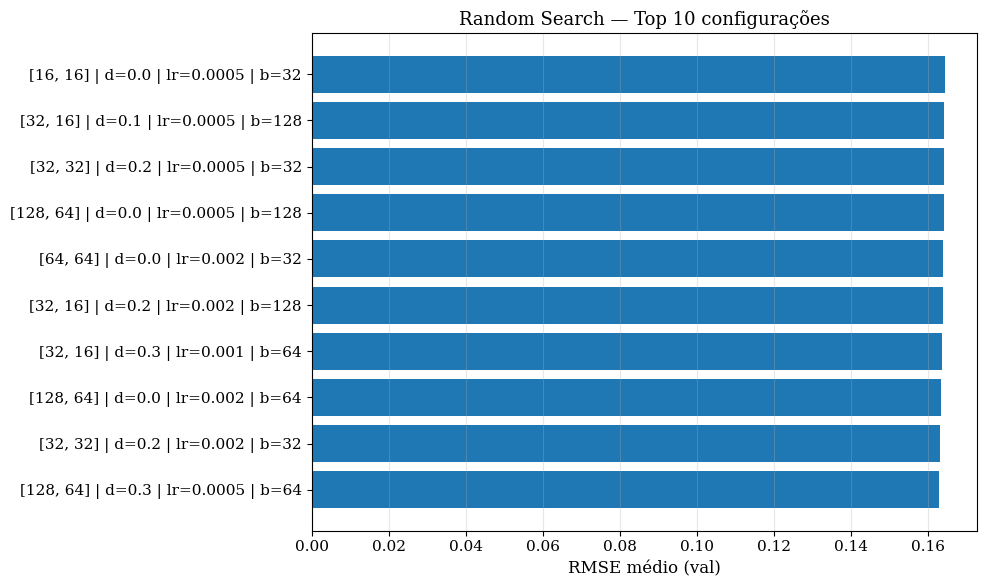

,hidden_layers,dropout,learning_rate,batch_size,patience,rmse_medio_mean,rmse_medio_std,rmse_lon_mean,rmse_lat_mean,mae_medio_mean,best_epoch_mean
5,"[128, 64]",0.3,0.000,64,20,0.163,0.021,0.174,0.152,0.117,33.75
11,"[32, 32]",0.2,0.002,32,20,0.163,0.021,0.175,0.152,0.117,17.50
2,"[128, 64]",0.0,0.002,64,10,0.164,0.021,0.175,0.152,0.118,4.25
17,"[32, 16]",0.3,0.001,64,20,0.164,0.020,0.176,0.151,0.117,50.75
15,"[32, 16]",0.2,0.002,128,20,0.164,0.020,0.176,0.152,0.118,28.50


In [ ]:
df_plot = df_rs_resumo.head(10).copy()
df_plot["label"] = (
    df_plot["hidden_layers"].astype(str)
    + " | d=" + df_plot["dropout"].astype(str)
    + " | lr=" + df_plot["learning_rate"].astype(str)
    + " | b=" + df_plot["batch_size"].astype(str)
)
df_plot = df_plot.sort_values("rmse_medio_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_plot["label"], df_plot["rmse_medio_mean"])
plt.xlabel("RMSE médio (val)")
plt.title("Random Search — Top 10 configurações")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rs_top10_rmse.png"), dpi=300, bbox_inches="tight")
plt.show()

# Tabela top 5 arredondada
cols_tabela = ["hidden_layers","dropout","learning_rate","batch_size","patience",
               "rmse_medio_mean","rmse_medio_std","rmse_lon_mean","rmse_lat_mean",
               "mae_medio_mean","best_epoch_mean"]
df_rs_resumo[cols_tabela].head(5).round(3)

## 8. Treino Final com a Melhor Configuração

In [ ]:
# ── Preencher com a melhor linha do df_rs_resumo ──────────────────────────────
melhor = df_rs_resumo.iloc[0]

BEST = dict(
    hidden_layers = eval(melhor["hidden_layers"]),   # converte string → lista
    dropout       = melhor["dropout"],
    learning_rate = melhor["learning_rate"],
    batch_size    = int(melhor["batch_size"]),
    patience      = int(melhor["patience"]),
)
print("Melhor configuração:", BEST)

# ── Separar treino final (85 %) e early-stopping interno (15 %) ───────────────
df_train_final = df_model.sort_values("timestamp_curr").copy()
cut = int(len(df_train_final) * 0.85)
df_tr_es = df_train_final.iloc[:cut].copy()
df_va_es = df_train_final.iloc[cut:].copy()

print(f"Treino ES: {len(df_tr_es)} | Val ES: {len(df_va_es)} | Teste: {len(df_test_final)}")

# ── Pré-processamento ─────────────────────────────────────────────────────────
dados_finais = preparar_dados(df_tr_es, df_va_es, FEATURES, TARGETS, BEST["batch_size"])

# Normalizar teste com o mesmo scaler (sem data leakage)
X_test_scaled = dados_finais["scaler_X"].transform(df_test_final[FEATURES].values)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_true   = df_test_final[TARGETS].values

# ── Instanciar e treinar ──────────────────────────────────────────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

model_final = MLPRegressorFlexible(
    input_dim=len(FEATURES),
    hidden_layers=BEST["hidden_layers"],
    output_dim=len(TARGETS),
    dropout=BEST["dropout"]
)
print(model_final)

model_final, train_losses, val_losses, best_ep = treinar_modelo(
    model_final,
    dados_finais["loader_tr"], dados_finais["loader_va"],
    learning_rate=BEST["learning_rate"],
    patience=BEST["patience"]
)
print(f"\nModelo final restaurado para a época {best_ep}.")


# ── Objetos finais para uso em outras células/notebooks ───────────────────────
model_reg = model_final
scaler_X = dados_finais["scaler_X"]
scaler_y = dados_finais["scaler_y"]
features_reg = FEATURES
target_reg = TARGETS

# ── MLP final: previsão no teste reservado ────────────────────────────────────
model_final.eval()

with torch.no_grad():
    y_pred_final = scaler_y.inverse_transform(
        model_final(X_test_tensor).numpy()
    )

m_mlp = calcular_metricas(y_test_true, y_pred_final)

# ── Salvar previsões da MLP no teste final ────────────────────────────────────
df_pred_test = df_test_final.copy()

df_pred_test["pred_delta_lon"] = y_pred_final[:, 0]
df_pred_test["pred_delta_lat"] = y_pred_final[:, 1]

df_pred_test["obs_delta_lon"] = y_test_true[:, 0]
df_pred_test["obs_delta_lat"] = y_test_true[:, 1]

df_pred_test["pred_next_lon"] = df_pred_test["lon_curr"] + df_pred_test["pred_delta_lon"]
df_pred_test["pred_next_lat"] = df_pred_test["lat_curr"] + df_pred_test["pred_delta_lat"]

df_pred_test["obs_next_lon"] = df_pred_test["lon_curr"] + df_pred_test["obs_delta_lon"]
df_pred_test["obs_next_lat"] = df_pred_test["lat_curr"] + df_pred_test["obs_delta_lat"]

df_pred_test["erro_delta_lon"] = df_pred_test["obs_delta_lon"] - df_pred_test["pred_delta_lon"]
df_pred_test["erro_delta_lat"] = df_pred_test["obs_delta_lat"] - df_pred_test["pred_delta_lat"]

df_pred_test["abs_erro_delta_lon"] = df_pred_test["erro_delta_lon"].abs()
df_pred_test["abs_erro_delta_lat"] = df_pred_test["erro_delta_lat"].abs()

pred_path = os.path.join(OUT_DIR, "previsoes_mlp_teste_final.csv")
df_pred_test.to_csv(pred_path, index=False)

pred_path_pv = os.path.join(OUT_DIR, "previsoes_mlp_teste_final_ponto_virgula.csv")
df_pred_test.to_csv(pred_path_pv, index=False, sep=";")

print("\nPrevisões da MLP salvas em:")
print(pred_path)
print(pred_path_pv)

# ── Baseline persistência ─────────────────────────────────────────────────────
y_baseline = df_test_final[["delta_lon", "delta_lat"]].values
m_base = calcular_metricas(y_test_true, y_baseline)

# ── Tabela de métricas ────────────────────────────────────────────────────────
df_metricas = pd.DataFrame([
    {"modelo": "MLP final",             **m_mlp},
    {"modelo": "Baseline persistência", **m_base},
])

print("\nMétricas finais:")
print(df_metricas.round(4).to_string(index=False))

metricas_path = os.path.join(OUT_DIR, "metricas_finais.csv")
df_metricas.to_csv(metricas_path, index=False)

print("\nMétricas salvas em:")
print(metricas_path)

Melhor configuração: {'hidden_layers': [128, 64], 'dropout': np.float64(0.3), 'learning_rate': np.float64(0.0005), 'batch_size': 64, 'patience': 20}
Treino ES: 734 | Val ES: 130 | Teste: 255
MLPRegressorFlexible(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)
  Época 010 | treino 0.7861 | val 0.5657 | melhor época 9
  Época 020 | treino 0.7619 | val 0.5649 | melhor época 9
  Early stopping na época 29 (melhor: 9, val: 0.5594)

Modelo final restaurado para a época 9.

Previsões da MLP salvas em:
/content/resultados_mlp/previsoes_mlp_teste_final.csv
/content/resultados_mlp/previsoes_mlp_teste_final_ponto_virgula.csv

Métricas finais:
               modelo  mae_lon  rmse_lon  r2_lon  mae_lat  rmse_lat  r2_lat  mae_medio  rm

## 9. Avaliação no Teste Reservado e Comparação com Baseline

In [ ]:
# ── MLP final ─────────────────────────────────────────────────────────────────
model_final.eval()
with torch.no_grad():
    y_pred_final = dados_finais["scaler_y"].inverse_transform(
        model_final(X_test_tensor).numpy()
    )

m_mlp = calcular_metricas(y_test_true, y_pred_final)

# ── Baseline persistência ──────────────────────────────────────────────────────
y_baseline = df_test_final[["delta_lon", "delta_lat"]].values
m_base     = calcular_metricas(y_test_true, y_baseline)

# ── Tabela de métricas ─────────────────────────────────────────────────────────
df_metricas = pd.DataFrame([
    {"modelo": "MLP final",              **m_mlp},
    {"modelo": "Baseline persistência",  **m_base},
])

print(df_metricas.round(4).to_string(index=False))

df_metricas.to_csv(os.path.join(OUT_DIR, "metricas_finais.csv"), index=False)
print("\nMétricas salvas.")

               modelo  mae_lon  rmse_lon  r2_lon  mae_lat  rmse_lat  r2_lat  mae_medio  rmse_medio
            MLP final   0.1379    0.1879  0.0864   0.0984    0.1384  0.2604     0.1181      0.1632
Baseline persistência   0.1431    0.2061 -0.0996   0.1129    0.1506  0.1248     0.1280      0.1784

Métricas salvas.


## 10. Figuras para o Artigo

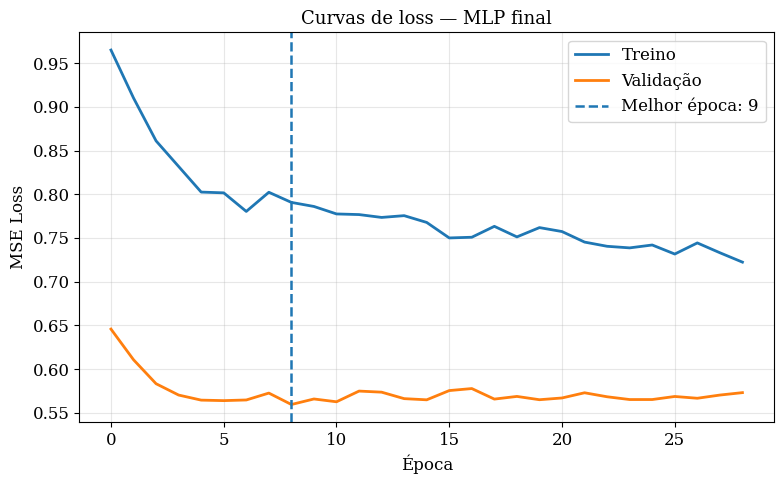

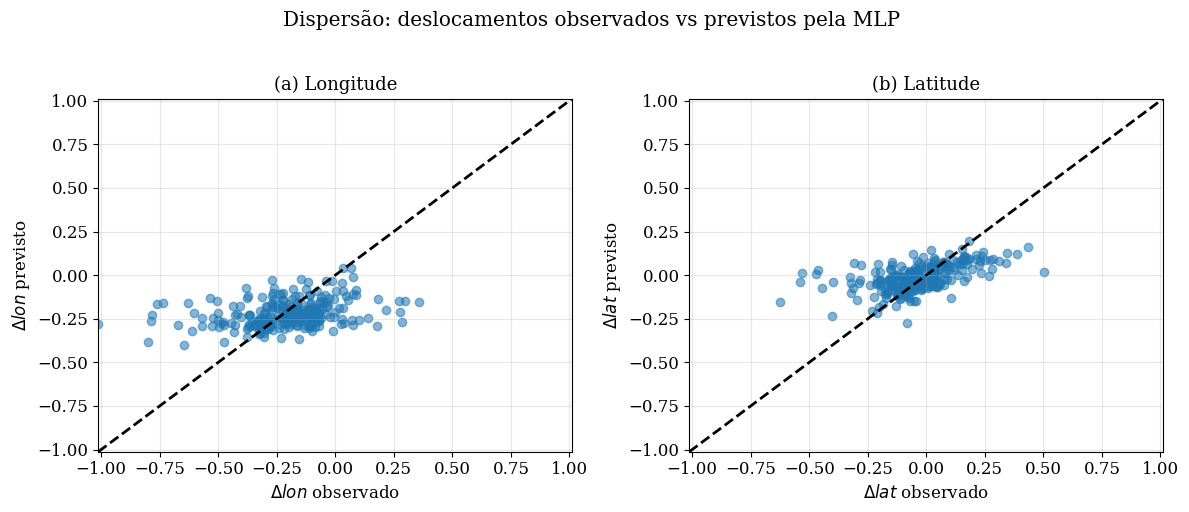

Todas as figuras salvas em: /content/resultados_mlp


In [ ]:
plt.rcParams.update({"font.family": "serif", "font.size": 12})

# ── Curvas de loss ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, linewidth=2, label="Treino")
ax.plot(val_losses,   linewidth=2, label="Validação")
ax.axvline(best_ep - 1, linestyle="--", linewidth=1.8, label=f"Melhor época: {best_ep}")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.set_title("Curvas de loss — MLP final")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "curvas_loss_mlp_final.png"), dpi=300, bbox_inches="tight")
plt.show()

# ── Dispersão observado × previsto ────────────────────────────────────────────
obs_lon, pred_lon = y_test_true[:, 0], y_pred_final[:, 0]
obs_lat, pred_lat = y_test_true[:, 1], y_pred_final[:, 1]

abs_lim = max(abs(np.concatenate([obs_lon, pred_lon, obs_lat, pred_lat])).max(), 0.01)
lims = (-abs_lim, abs_lim)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, obs, pred, xlabel, ylabel, titulo in [
    (axes[0], obs_lon, pred_lon, r"$\Delta lon$ observado", r"$\Delta lon$ previsto", "(a) Longitude"),
    (axes[1], obs_lat, pred_lat, r"$\Delta lat$ observado", r"$\Delta lat$ previsto", "(b) Latitude"),
]:
    ax.scatter(obs, pred, alpha=0.55)
    ax.plot(lims, lims, "k--", linewidth=2)
    ax.set_xlim(*lims)
    ax.set_ylim(*lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    ax.grid(alpha=0.3)

plt.suptitle("Dispersão: deslocamentos observados vs previstos pela MLP", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "scatter_mlp_final.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Todas as figuras salvas em:", OUT_DIR)